In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "ACSST1Y2024.S1902-2026-05-08T012308.csv"

df = pd.read_csv(file_path)

df.head(10)

,Label (Grouping),Massachusetts!!Number!!Estimate,Massachusetts!!Number!!Margin of Error,Massachusetts!!Percent Distribution!!Estimate,Massachusetts!!Percent Distribution!!Margin of Error,Massachusetts!!Mean income (dollars)!!Estimate,Massachusetts!!Mean income (dollars)!!Margin of Error,"Boston city, Massachusetts!!Number!!Estimate","Boston city, Massachusetts!!Number!!Margin of Error","Boston city, Massachusetts!!Percent Distribution!!Estimate","Boston city, Massachusetts!!Percent Distribution!!Margin of Error","Boston city, Massachusetts!!Mean income (dollars)!!Estimate","Boston city, Massachusetts!!Mean income (dollars)!!Margin of Error"
0,HOUSEHOLD INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,All households,"2,829,804","±9,140","2,829,804","±9,140","144,312","±1,304","294,977","±3,333","294,977","±3,333","138,724","±5,206"
2,With earnings,"2,226,456","±11,252",78.7%,±0.3,"149,436","±1,513","238,679","±5,436",80.9%,±1.4,"147,632","±4,750"
3,With wages or salary income,"2,160,543","±12,511",76.3%,±0.4,"146,494","±1,441","234,329","±5,448",79.4%,±1.5,"145,324","±4,915"
4,With self-employment income,"310,653","±9,386",11.0%,±0.3,"52,170","±3,270","27,637","±2,832",9.4%,±1.0,"42,809","±12,737"
5,"With interest, dividends, or net renta...","725,865","±13,198",25.7%,±0.5,"32,557","±2,251","71,037","±4,722",24.1%,±1.5,"36,528","±10,365"
6,With Social Security income,"872,672","±10,854",30.8%,±0.4,"25,232",±325,"63,049","±3,320",21.4%,±1.1,"21,709","±1,387"
7,With Supplemental Security Income (SSI),"151,041","±6,430",5.3%,±0.2,"10,918",±348,"20,624","±3,177",7.0%,±1.1,"10,561",±768
8,With cash public assistance income or ...,"454,353","±10,564",16.1%,±0.4,(X),(X),"65,125","±3,882",22.1%,±1.3,(X),(X)
9,With cash public assistance,"95,822","±5,743",3.4%,±0.2,"4,294",±300,"12,078","±2,060",4.1%,±0.7,"4,057",±761


In [2]:
label_col = "Label (Grouping)"
income_col = "Boston city, Massachusetts!!Mean income (dollars)!!Estimate"
moe_col = "Boston city, Massachusetts!!Mean income (dollars)!!Margin of Error"

df[[label_col, income_col, moe_col]].head(50)

,Label (Grouping),"Boston city, Massachusetts!!Mean income (dollars)!!Estimate","Boston city, Massachusetts!!Mean income (dollars)!!Margin of Error"
0,HOUSEHOLD INCOME,NaN,NaN
1,All households,"138,724","±5,206"
2,With earnings,"147,632","±4,750"
3,With wages or salary income,"145,324","±4,915"
4,With self-employment income,"42,809","±12,737"
5,"With interest, dividends, or net renta...","36,528","±10,365"
6,With Social Security income,"21,709","±1,387"
7,With Supplemental Security Income (SSI),"10,561",±768
8,With cash public assistance income or ...,(X),(X)
9,With cash public assistance,"4,057",±761


In [3]:
income_df = df[[label_col, income_col, moe_col]].copy()

income_df.columns = ["group", "mean_income", "moe"]

# Clean group names
income_df["group"] = (
    income_df["group"]
    .astype(str)
    .str.replace("�", "", regex=False)
    .str.strip()
)

# Clean income numbers
income_df["mean_income"] = (
    income_df["mean_income"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("�", "", regex=False)
    .str.replace("(X)", "", regex=False)
    .str.strip()
)

income_df["mean_income"] = pd.to_numeric(income_df["mean_income"], errors="coerce")

income_df.head(60)

,group,mean_income,moe
0,HOUSEHOLD INCOME,NaN,NaN
1,All households,138724.0,"±5,206"
2,With earnings,147632.0,"±4,750"
3,With wages or salary income,145324.0,"±4,915"
4,With self-employment income,42809.0,"±12,737"
5,"With interest, dividends, or net rental income",36528.0,"±10,365"
6,With Social Security income,21709.0,"±1,387"
7,With Supplemental Security Income (SSI),10561.0,±768
8,With cash public assistance income or Food Sta...,NaN,(X)
9,With cash public assistance,4057.0,±761


In [4]:
income_df[income_df["group"].str.contains(
    "White|Black|Asian|Hispanic|Latino|American Indian|Native Hawaiian|Two or more",
    case=False,
    na=False
)]

,group,mean_income,moe
20,PER CAPITA INCOME BY RACE AND HISPANIC OR LATI...,NaN,NaN
23,White,87062.0,"±3,816"
24,Black or African American,32877.0,"±2,912"
25,American Indian and Alaska Native,34728.0,"±10,944"
26,Asian,56452.0,"±8,804"
27,Native Hawaiian and Other Pacific Islander,NaN,N
29,Two or more races,37266.0,"±3,514"
30,Hispanic or Latino origin (of any race),31632.0,"±2,301"
31,"White alone, not Hispanic or Latino",89252.0,"±3,862"


In [5]:
ethnicity_income = income_df[income_df["group"].str.contains(
    "White alone|Black alone|Asian alone|Hispanic or Latino",
    case=False,
    na=False
)].copy()

ethnicity_income

,group,mean_income,moe
20,PER CAPITA INCOME BY RACE AND HISPANIC OR LATI...,NaN,NaN
30,Hispanic or Latino origin (of any race),31632.0,"±2,301"
31,"White alone, not Hispanic or Latino",89252.0,"±3,862"


In [6]:
overall_mean = ethnicity_income["mean_income"].mean()

ethnicity_income["percent_difference"] = (
    (ethnicity_income["mean_income"] - overall_mean) / overall_mean
) * 100

ethnicity_income

,group,mean_income,moe,percent_difference
20,PER CAPITA INCOME BY RACE AND HISPANIC OR LATI...,NaN,NaN,NaN
30,Hispanic or Latino origin (of any race),31632.0,"±2,301",-47.665531
31,"White alone, not Hispanic or Latino",89252.0,"±3,862",47.665531


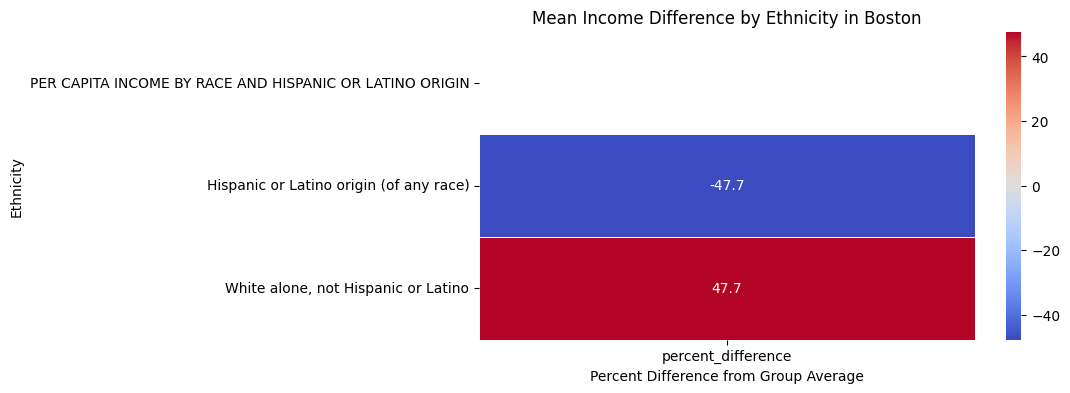

In [7]:
heatmap_data = ethnicity_income.set_index("group")[["percent_difference"]]

plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Mean Income Difference by Ethnicity in Boston")
plt.xlabel("Percent Difference from Group Average")
plt.ylabel("Ethnicity")
plt.show()